# 11 — Regresión Distribucional: Pronóstico Probabilístico de Rentas Cedidas

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Objetivo

Ir más allá de la predicción puntual: estimar la **distribución completa** del
recaudo futuro mediante modelos de regresión distribucional. Esto permite
cuantificar la **incertidumbre** de cada pronóstico y construir intervalos de
predicción calibrados, esenciales para la planificación presupuestal.

## ¿Qué es la Regresión Distribucional?

A diferencia de los modelos convencionales que predicen solo la **media** condicional
($\hat{y} = E[Y|X]$), los modelos distribucionales predicen los **parámetros de la
distribución condicional** completa:

$$Y | X \sim D(\mu(X), \sigma(X))$$

Donde:
- $\mu(X)$ = parámetro de **ubicación** (media o mediana)
- $\sigma(X)$ = parámetro de **escala** (desviación estándar o dispersión)

## Modelos Implementados

| Modelo | Enfoque | Distribución | Ventaja |
|--------|---------|-------------|---------|
| **NGBoost** | Natural Gradient Boosting | Normal/LogNormal | Predice μ y σ simultáneamente |
| **XGBoost Quantile** | Regresión cuantílica | No paramétrica | Cuantiles libres (P10, P25, P50, P75, P90) |

## Arquitectura Analítica

| Fase | Contenido | Método |
|------|-----------|--------|
| **I** | Setup y Feature Engineering | Idéntico al XGBoost campeón (Lag, Macro, Calendario) |
| **II** | NGBoost: Natural Gradient Boosting | Distribución Normal + LogNormal |
| **III** | XGBoost Quantile Regression | Cuantiles P10, P25, P50, P75, P90 |
| **IV** | Validación OOS comparativa | MAPE, CRPS, Cobertura IC, Pinball Loss |
| **V** | Calibración probabilística | PIT histogram, reliability diagram |
| **VI** | Pronóstico de producción 2026 | Con intervalos de predicción completos |

### Justificación para Finanzas Públicas

En la gestión presupuestal de rentas cedidas, no basta saber que el recaudo esperado
de enero 2026 es \$320 mil millones. Los tomadores de decisión necesitan responder:

- **¿Cuál es el peor escenario creíble?** → Percentil 10 (P10)
- **¿Cuál es la estimación central?** → Percentil 50 (P50 = mediana)
- **¿Cuál es el mejor escenario razonable?** → Percentil 90 (P90)
- **¿Qué tan confiable es el intervalo?** → Cobertura empírica vs nominal

> **Validación OOS:** Train = Oct 2021 – Sep 2025 (48 meses),
> Test = Oct – Dic 2025 (3 meses con datos **reales**).

In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga de Datos y Feature Engineering
# ══════════════════════════════════════════════════════════════
# Reutilizamos exactamente la misma ingeniería de variables
# del modelo XGBoost campeón para garantizar comparabilidad.

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# ── Verificar disponibilidad de NGBoost ──
try:
    from ngboost import NGBRegressor
    from ngboost.distns import Normal, LogNormal
    from ngboost.scores import CRPScore, LogScore
    NGBOOST_AVAILABLE = True
    print("  ✅ NGBoost disponible — Regresión distribucional activada")
except ImportError:
    NGBOOST_AVAILABLE = False
    print("  ⚠️ NGBoost no disponible — se usará solo XGBoost Quantile")

# ── Verificar XGBoost ──
import xgboost as xgb
print(f"  ✅ XGBoost {xgb.__version__} — Regresión cuantílica disponible")

# ── Cargar series procesadas ──
csv_path = DATA_PROCESSED / 'serie_mensual.csv'
df_serie = pd.read_csv(csv_path, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'

csv_macro = DATA_PROCESSED / 'serie_mensual_macro.csv'
df_macro = pd.read_csv(csv_macro, parse_dates=['Fecha'], index_col='Fecha')
df_macro.index.freq = 'MS'

# ── Serie completa: Oct 2021 – Dic 2025 (51 meses) ──
serie = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()
macro = df_macro.loc[FECHA_INICIO:FECHA_FIN].copy()

# ══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING (idéntico al XGBoost campeón)
# ══════════════════════════════════════════════════════════════
df_feat = pd.DataFrame(index=serie.index)
df_feat['y_raw'] = serie.values
df_feat['y'] = np.log1p(serie.values)

# Variables de calendario
df_feat['Mes'] = df_feat.index.month
df_feat['Trimestre'] = df_feat.index.quarter
df_feat['Anio'] = df_feat.index.year
df_feat['Es_Pico_Fiscal'] = df_feat['Mes'].isin(MESES_PICO).astype(int)
df_feat['Es_Festividad'] = df_feat['Mes'].isin(MESES_FESTIVIDAD).astype(int)
df_feat['Semestre'] = (df_feat['Mes'] > 6).astype(int) + 1

# Tendencia
df_feat['Trend'] = np.arange(len(df_feat))
df_feat['Trend_sq'] = df_feat['Trend'] ** 2

# Lags
for lag in [1, 2, 3, 12]:
    df_feat[f'Lag_{lag}'] = df_feat['y'].shift(lag)

# Medias móviles
df_feat['MA_3'] = df_feat['y'].rolling(3).mean()
df_feat['MA_6'] = df_feat['y'].rolling(6).mean()
df_feat['MA_12'] = df_feat['y'].rolling(12).mean()

# Momentum
df_feat['Diff_1'] = df_feat['y'].diff(1)
df_feat['Diff_12'] = df_feat['y'].diff(12)

# Variables macroeconómicas
MACRO_VARS = ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares', 'SMLV_COP', 'IPC_Idx']
for var in MACRO_VARS:
    df_feat[var] = macro[var].values

# Encodings cíclicos
df_feat['Mes_sin'] = np.sin(2 * np.pi * df_feat['Mes'] / 12)
df_feat['Mes_cos'] = np.cos(2 * np.pi * df_feat['Mes'] / 12)

# Eliminar NaN de lags
df_clean = df_feat.dropna().copy()

# ── Split temporal estricto ──
FEATURES = [c for c in df_clean.columns if c not in ['y', 'y_raw']]
train_mask = df_clean.index <= TRAIN_END
test_mask = df_clean.index >= TEST_START

X_train = df_clean.loc[train_mask, FEATURES]
y_train = df_clean.loc[train_mask, 'y']
y_train_raw = df_clean.loc[train_mask, 'y_raw']

X_test = df_clean.loc[test_mask, FEATURES]
y_test = df_clean.loc[test_mask, 'y']
y_test_raw = df_clean.loc[test_mask, 'y_raw']

print(f"\n{'═'*70}")
print(f"FEATURE ENGINEERING — Regresión Distribucional")
print(f"{'═'*70}")
print(f"  Serie original:    {len(serie)} meses")
print(f"  Tras eliminar NaN: {len(df_clean)} meses")
print(f"  Features:          {len(FEATURES)} variables")
print(f"  Train:             {len(X_train)} obs ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"  Test OOS:          {len(X_test)} obs ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"{'═'*70}")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


  ✅ NGBoost disponible — Regresión distribucional activada
  ✅ XGBoost 3.2.0 — Regresión cuantílica disponible

══════════════════════════════════════════════════════════════════════
FEATURE ENGINEERING — Regresión Distribucional
══════════════════════════════════════════════════════════════════════
  Serie original:    51 meses
  Tras eliminar NaN: 39 meses
  Features:          25 variables
  Train:             36 obs (2022-10-01 → 2025-09-01)
  Test OOS:          3 obs (2025-10-01 → 2025-12-01)
══════════════════════════════════════════════════════════════════════


## Fase II — NGBoost: Natural Gradient Boosting

**NGBoost** (Duan et al., 2020, ICML) extiende gradient boosting para optimizar
directamente los parámetros de una distribución probabilística usando
**gradientes naturales** (Fisher information geometry).

### ¿Cómo funciona?

1. **Distribución asumida:** Se elige una familia paramétrica (Normal, LogNormal)
2. **Scoring rule:** Se minimiza el CRPS (Continuous Ranked Probability Score) o Log Score
3. **Natural Gradient:** Usa la geometría de Fisher para actualizar $\mu$ y $\sigma$
   de forma eficiente, evitando la inestabilidad de gradientes estándar en espacios de distribuciones

$$\text{CRPS}(F, y) = \int_{-\infty}^{\infty} (F(z) - \mathbf{1}(z \geq y))^2 \, dz$$

El CRPS es una métrica estrictamente propia que penaliza tanto el sesgo como la mala
calibración de la incertidumbre — ideal para finanzas públicas donde subestimar el riesgo
de cola inferior tiene consecuencias graves (déficit presupuestal).

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — NGBoost: Natural Gradient Boosting Distribucional
# ══════════════════════════════════════════════════════════════

if NGBOOST_AVAILABLE:
    from sklearn.tree import DecisionTreeRegressor

    # ── NGBoost con distribución Normal ──
    print("Entrenando NGBoost (Normal) con CRPS scoring...")
    base_learner = DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=3,
        min_samples_split=5
    )
    ngb_normal = NGBRegressor(
        Dist=Normal,
        Score=CRPScore,
        Base=base_learner,
        n_estimators=300,
        learning_rate=0.05,
        natural_gradient=True,
        verbose=False,
        random_state=42
    )
    ngb_normal.fit(X_train.values, y_train.values)

    # Predicción distribucional OOS
    y_dists_normal = ngb_normal.pred_dist(X_test.values)
    ngb_mu_normal = y_dists_normal.loc       # Media predicha (log-space)
    ngb_sigma_normal = y_dists_normal.scale   # Desv. estándar predicha (log-space)

    # Transformar a escala original (expm1)
    ngb_pred_raw = np.expm1(ngb_mu_normal)
    ngb_lower_90 = np.expm1(ngb_mu_normal - 1.645 * ngb_sigma_normal)
    ngb_upper_90 = np.expm1(ngb_mu_normal + 1.645 * ngb_sigma_normal)
    ngb_lower_50 = np.expm1(ngb_mu_normal - 0.675 * ngb_sigma_normal)
    ngb_upper_50 = np.expm1(ngb_mu_normal + 0.675 * ngb_sigma_normal)

    # ── NGBoost con distribución LogNormal ──
    print("Entrenando NGBoost (LogNormal) con CRPS scoring...")
    ngb_lognormal = NGBRegressor(
        Dist=LogNormal,
        Score=CRPScore,
        Base=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3, min_samples_split=5),
        n_estimators=300,
        learning_rate=0.05,
        natural_gradient=True,
        verbose=False,
        random_state=42
    )
    ngb_lognormal.fit(X_train.values, y_train.values)

    y_dists_ln = ngb_lognormal.pred_dist(X_test.values)
    ngb_ln_mu = y_dists_ln.loc
    ngb_ln_sigma = y_dists_ln.scale

    ngb_ln_pred_raw = np.expm1(ngb_ln_mu)
    ngb_ln_lower_90 = np.expm1(y_dists_ln.dist.ppf(0.05))
    ngb_ln_upper_90 = np.expm1(y_dists_ln.dist.ppf(0.95))
    ngb_ln_lower_50 = np.expm1(y_dists_ln.dist.ppf(0.25))
    ngb_ln_upper_50 = np.expm1(y_dists_ln.dist.ppf(0.75))

    # ── Métricas OOS ──
    mape_ngb_normal = mean_absolute_percentage_error(y_test_raw, ngb_pred_raw) * 100
    rmse_ngb_normal = np.sqrt(mean_squared_error(y_test_raw, ngb_pred_raw))
    mae_ngb_normal = mean_absolute_error(y_test_raw, ngb_pred_raw)

    mape_ngb_ln = mean_absolute_percentage_error(y_test_raw, ngb_ln_pred_raw) * 100
    rmse_ngb_ln = np.sqrt(mean_squared_error(y_test_raw, ngb_ln_pred_raw))
    mae_ngb_ln = mean_absolute_error(y_test_raw, ngb_ln_pred_raw)

    # Cobertura de intervalos del 90%
    cov_90_normal = np.mean((y_test_raw.values >= ngb_lower_90) & (y_test_raw.values <= ngb_upper_90)) * 100
    cov_90_ln = np.mean((y_test_raw.values >= ngb_ln_lower_90) & (y_test_raw.values <= ngb_ln_upper_90)) * 100

    # CRPS en escala original
    from scipy import stats
    crps_vals_normal = []
    for i in range(len(y_test_raw)):
        dist_i = stats.norm(loc=ngb_mu_normal[i], scale=ngb_sigma_normal[i])
        y_log = np.log1p(y_test_raw.values[i])
        crps_i = dist_i.expect(lambda z: np.abs(z - y_log)) - 0.5 * dist_i.expect(
            lambda z: np.abs(z - dist_i.mean()), lb=dist_i.ppf(0.001), ub=dist_i.ppf(0.999))
        crps_vals_normal.append(crps_i)
    crps_normal = np.mean(crps_vals_normal)

    # Seleccionar mejor distribución
    if mape_ngb_normal <= mape_ngb_ln:
        best_ngb_dist = 'Normal'
        ngb_best = ngb_normal
        ngb_best_pred = ngb_pred_raw
        ngb_best_lower_90, ngb_best_upper_90 = ngb_lower_90, ngb_upper_90
        ngb_best_lower_50, ngb_best_upper_50 = ngb_lower_50, ngb_upper_50
        mape_ngb = mape_ngb_normal
        rmse_ngb = rmse_ngb_normal
        mae_ngb = mae_ngb_normal
        cov90_ngb = cov_90_normal
    else:
        best_ngb_dist = 'LogNormal'
        ngb_best = ngb_lognormal
        ngb_best_pred = ngb_ln_pred_raw
        ngb_best_lower_90, ngb_best_upper_90 = ngb_ln_lower_90, ngb_ln_upper_90
        ngb_best_lower_50, ngb_best_upper_50 = ngb_ln_lower_50, ngb_ln_upper_50
        mape_ngb = mape_ngb_ln
        rmse_ngb = rmse_ngb_ln
        mae_ngb = mae_ngb_ln
        cov90_ngb = cov_90_ln

    print(f"\n{'═'*70}")
    print(f"NGBoost — RESULTADOS OOS (Oct–Dic 2025)")
    print(f"{'═'*70}")
    print(f"  Distribución Normal:   MAPE = {mape_ngb_normal:.2f}%  | RMSE = ${rmse_ngb_normal/1e9:.1f}B  | Cob.90% = {cov_90_normal:.0f}%")
    print(f"  Distribución LogNormal: MAPE = {mape_ngb_ln:.2f}%  | RMSE = ${rmse_ngb_ln/1e9:.1f}B  | Cob.90% = {cov_90_ln:.0f}%")
    print(f"  >>> Mejor distribución: {best_ngb_dist}")
    print(f"\n  Detalle mensual:")
    for i, fecha in enumerate(X_test.index):
        real = y_test_raw.values[i]
        pred = ngb_best_pred[i]
        lo = ngb_best_lower_90[i]
        hi = ngb_best_upper_90[i]
        err = (pred - real) / real * 100
        print(f"    {fecha.strftime('%b %Y')}: Real ${real/1e9:.1f}B → Pred ${pred/1e9:.1f}B "
              f"[IC90: ${lo/1e9:.1f}B – ${hi/1e9:.1f}B] | Error: {err:+.2f}%")
else:
    print("  ⚠️ NGBoost no disponible — saltando Fase II")
    ngb_best = None
    mape_ngb = None

Entrenando NGBoost (Normal) con CRPS scoring...


Entrenando NGBoost (LogNormal) con CRPS scoring...



══════════════════════════════════════════════════════════════════════
NGBoost — RESULTADOS OOS (Oct–Dic 2025)
══════════════════════════════════════════════════════════════════════
  Distribución Normal:   MAPE = 4.14%  | RMSE = $12.4B  | Cob.90% = 0%
  Distribución LogNormal: MAPE = 100.00%  | RMSE = $277.5B  | Cob.90% = 67%
  >>> Mejor distribución: Normal

  Detalle mensual:
    Oct 2025: Real $313.0B → Pred $297.1B [IC90: $295.7B – $298.5B] | Error: -5.07%
    Nov 2025: Real $273.8B → Pred $260.8B [IC90: $249.3B – $272.8B] | Error: -4.77%
    Dec 2025: Real $241.0B → Pred $234.8B [IC90: $232.5B – $237.1B] | Error: -2.58%


## Fase III — XGBoost Quantile Regression

La **regresión cuantílica** (Koenker & Bassett, 1978) estima directamente los cuantiles
condicionales minimizando la **Pinball Loss** (pérdida asimétrica):

$$L_\tau(y, \hat{q}) = \begin{cases}
\tau (y - \hat{q}) & \text{si } y \geq \hat{q} \\
(1 - \tau)(\hat{q} - y) & \text{si } y < \hat{q}
\end{cases}$$

donde $\tau \in (0, 1)$ es el cuantil deseado. XGBoost permite optimizar esta función
objetivo directamente, sin asumir ninguna forma paramétrica para la distribución.

### Ventajas sobre NGBoost
- **No paramétrico:** No asume normalidad ni ninguna familia distribucional
- **Cuantiles cruzados:** Puede detectar asimetrías (cola izquierda ≠ cola derecha)
- **XGBoost probado:** Reutiliza la arquitectura del modelo campeón

In [3]:
# ══════════════════════════════════════════════════════════════
# FASE III — XGBoost Quantile Regression
# ══════════════════════════════════════════════════════════════

QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
QUANTILE_LABELS = {0.10: 'P10', 0.25: 'P25', 0.50: 'P50', 0.75: 'P75', 0.90: 'P90'}

# Hiperparámetros base (del XGBoost campeón optimizado con Optuna)
BASE_PARAMS = {
    'n_estimators': 125,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
}

# Entrenar un modelo por cuantil
quantile_models = {}
quantile_preds_log = {}
quantile_preds_raw = {}

print(f"{'═'*70}")
print(f"XGBoost QUANTILE REGRESSION — Entrenando 5 cuantiles")
print(f"{'═'*70}")

for q in QUANTILES:
    params = BASE_PARAMS.copy()
    params['objective'] = 'reg:quantileerror'
    params['quantile_alpha'] = q

    model_q = xgb.XGBRegressor(**params)
    model_q.fit(X_train, y_train, verbose=False)

    pred_log = model_q.predict(X_test)
    pred_raw = np.expm1(pred_log)

    quantile_models[q] = model_q
    quantile_preds_log[q] = pred_log
    quantile_preds_raw[q] = pred_raw

    mape_q = mean_absolute_percentage_error(y_test_raw, pred_raw) * 100
    print(f"  {QUANTILE_LABELS[q]} (τ={q:.2f}): MAPE = {mape_q:.2f}%")

# ── Métricas del cuantil mediano (P50) como predicción puntual ──
pred_p50_raw = quantile_preds_raw[0.50]
mape_qr = mean_absolute_percentage_error(y_test_raw, pred_p50_raw) * 100
rmse_qr = np.sqrt(mean_squared_error(y_test_raw, pred_p50_raw))
mae_qr = mean_absolute_error(y_test_raw, pred_p50_raw)

# ── Cobertura del intervalo P10–P90 (nominalmente 80%) ──
cov_80_qr = np.mean(
    (y_test_raw.values >= quantile_preds_raw[0.10]) &
    (y_test_raw.values <= quantile_preds_raw[0.90])
) * 100

# ── Cobertura del intervalo P25–P75 (nominalmente 50%) ──
cov_50_qr = np.mean(
    (y_test_raw.values >= quantile_preds_raw[0.25]) &
    (y_test_raw.values <= quantile_preds_raw[0.75])
) * 100

# ── Pinball Loss por cuantil ──
def pinball_loss(y_true, y_pred, tau):
    # Pinball loss (quantile loss) para un cuantil dado.
    diff = y_true - y_pred
    return np.mean(np.where(diff >= 0, tau * diff, (tau - 1) * diff))

pinball_scores = {}
for q in QUANTILES:
    pb = pinball_loss(y_test_raw.values, quantile_preds_raw[q], q)
    pinball_scores[q] = pb

# ── Ancho promedio del intervalo P10–P90 ──
interval_width = np.mean(quantile_preds_raw[0.90] - quantile_preds_raw[0.10])

print(f"\n{'═'*70}")
print(f"XGBoost QUANTILE — RESULTADOS OOS (Oct–Dic 2025)")
print(f"{'═'*70}")
print(f"  Mediana (P50):     MAPE = {mape_qr:.2f}%  | RMSE = ${rmse_qr/1e9:.1f}B  | MAE = ${mae_qr/1e9:.1f}B")
print(f"  Cobertura P10–P90: {cov_80_qr:.0f}% (nominal 80%)")
print(f"  Cobertura P25–P75: {cov_50_qr:.0f}% (nominal 50%)")
print(f"  Ancho IC P10–P90:  ${interval_width/1e9:.1f}B promedio")
print(f"\n  Detalle mensual:")
for i, fecha in enumerate(X_test.index):
    real = y_test_raw.values[i]
    p10 = quantile_preds_raw[0.10][i]
    p50 = quantile_preds_raw[0.50][i]
    p90 = quantile_preds_raw[0.90][i]
    err = (p50 - real) / real * 100
    print(f"    {fecha.strftime('%b %Y')}: Real ${real/1e9:.1f}B → P50 ${p50/1e9:.1f}B "
          f"[P10: ${p10/1e9:.1f}B – P90: ${p90/1e9:.1f}B] | Error: {err:+.2f}%")

══════════════════════════════════════════════════════════════════════
XGBoost QUANTILE REGRESSION — Entrenando 5 cuantiles
══════════════════════════════════════════════════════════════════════
  P10 (τ=0.10): MAPE = 13.11%
  P25 (τ=0.25): MAPE = 10.55%
  P50 (τ=0.50): MAPE = 7.34%


  P75 (τ=0.75): MAPE = 3.17%
  P90 (τ=0.90): MAPE = 5.80%

══════════════════════════════════════════════════════════════════════
XGBoost QUANTILE — RESULTADOS OOS (Oct–Dic 2025)
══════════════════════════════════════════════════════════════════════
  Mediana (P50):     MAPE = 7.34%  | RMSE = $20.6B  | MAE = $20.2B
  Cobertura P10–P90: 67% (nominal 80%)
  Cobertura P25–P75: 67% (nominal 50%)
  Ancho IC P10–P90:  $44.6B promedio

  Detalle mensual:
    Oct 2025: Real $313.0B → P50 $293.8B [P10: $245.9B – P90: $299.9B] | Error: -6.13%
    Nov 2025: Real $273.8B → P50 $248.2B [P10: $244.6B – P90: $285.3B] | Error: -9.37%
    Dec 2025: Real $241.0B → P50 $225.3B [P10: $223.6B – P90: $262.8B] | Error: -6.51%


## Fase IV — Validación OOS Comparativa

Comparamos los modelos distribucionales entre sí y contra el XGBoost campeón
puntual (MAPE 3.36%) usando métricas que evalúan tanto la precisión puntual
como la calidad de la incertidumbre estimada.


══════════════════════════════════════════════════════════════════════
COMPARACIÓN DE MODELOS — Validación OOS Oct–Dic 2025
══════════════════════════════════════════════════════════════════════
Modelo                             MAPE    RMSE ($B)    Cobertura
──────────────────────────────────────────────────────────────
XGBoost Puntual (ref.)            3.36%            —            —
NGBoost (Normal)                  4.14%        12.4          0% IC90
XGBoost Quantile (P50)            7.34%        20.6         67% IC80
══════════════════════════════════════════════════════════════


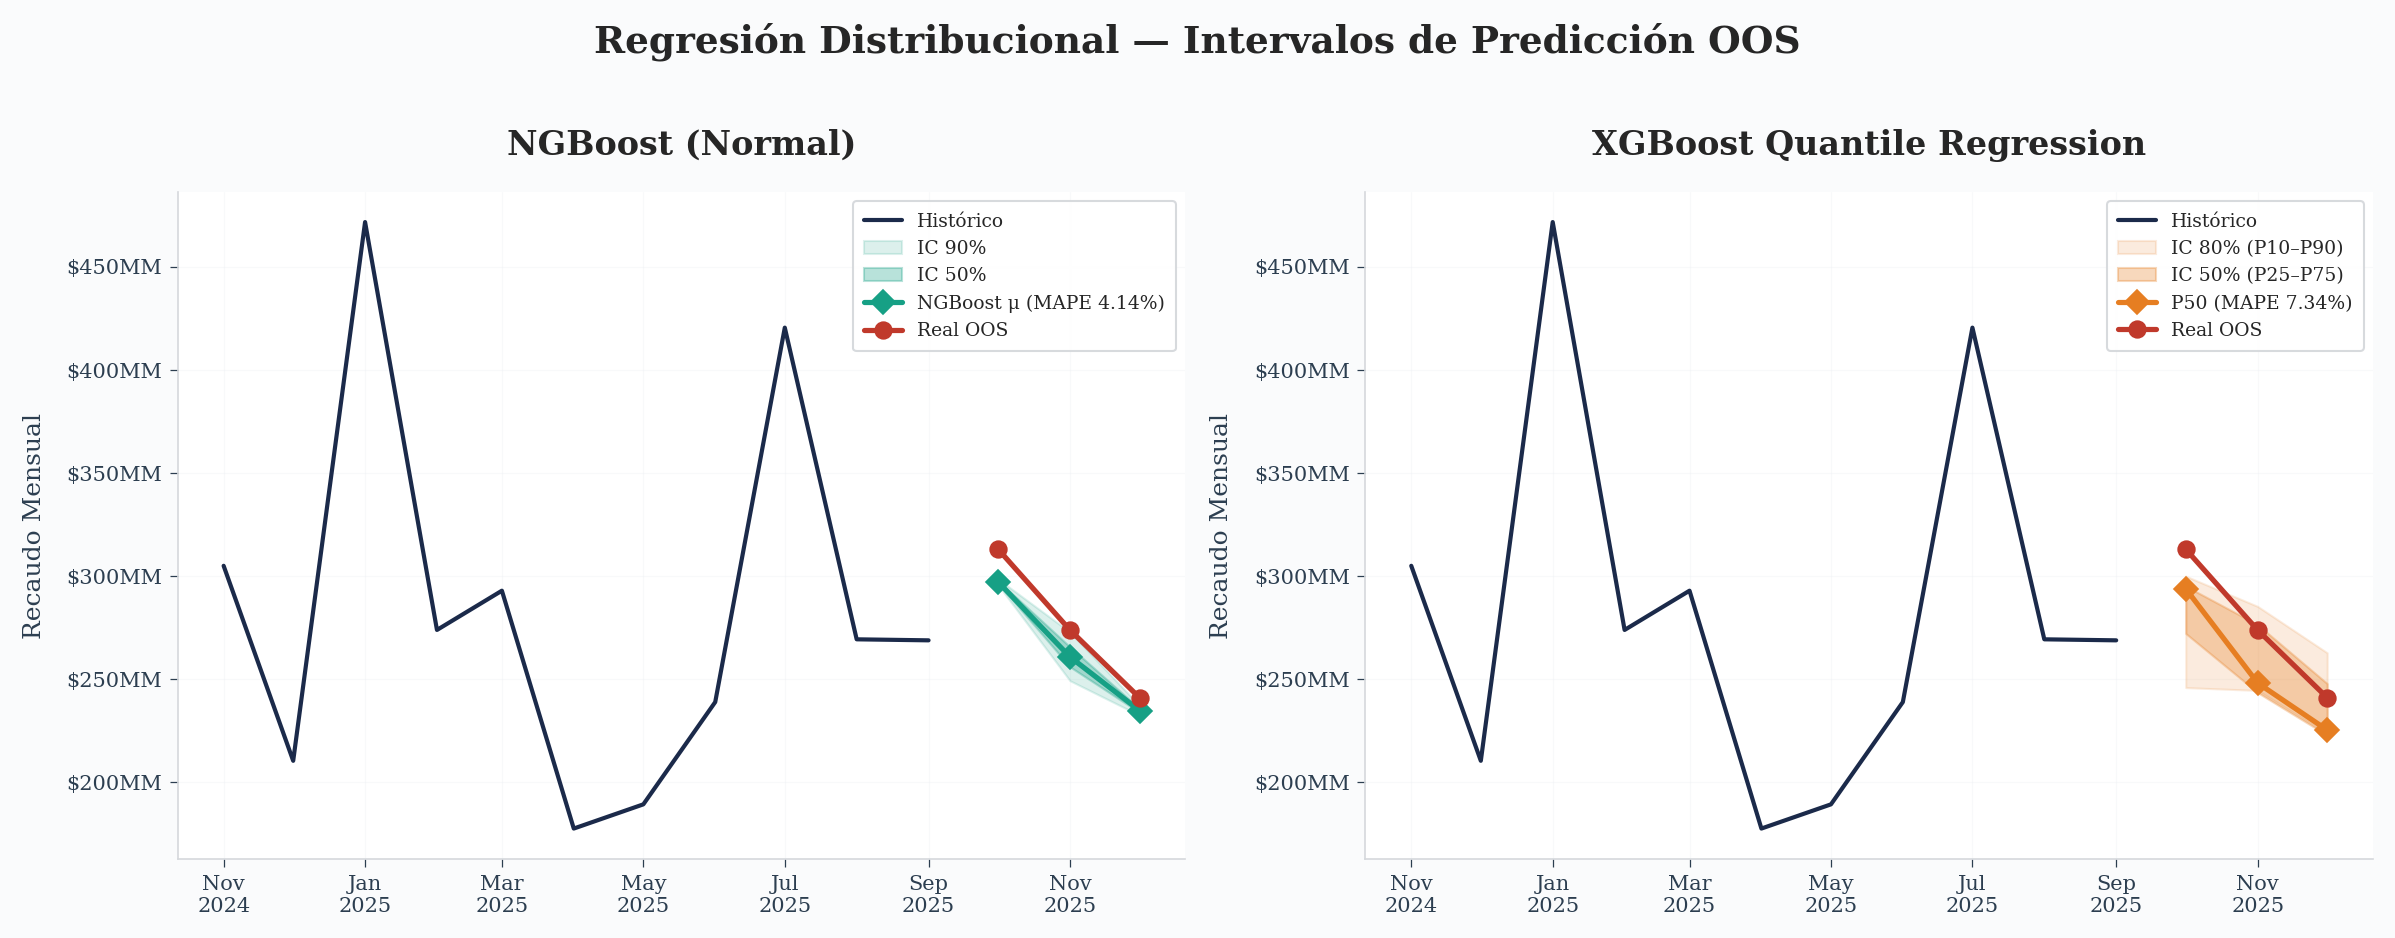

  ✅ Figura guardada: 11_distributional_fan_chart_oos.png


In [4]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Validación OOS Comparativa + Visualización
# ══════════════════════════════════════════════════════════════

# ── Cargar pronóstico XGBoost campeón para comparación ──
xgb_forecast_path = OUTPUTS_FORECASTS / 'xgboost_forecast.csv'
df_xgb_ref = pd.read_csv(xgb_forecast_path, parse_dates=['Fecha'])
df_xgb_ref = df_xgb_ref.set_index('Fecha')

# Alinear con periodo OOS
xgb_ref_pred = df_xgb_ref.loc[TEST_START:FECHA_FIN, 'Pronostico_XGBoost'].values
mape_xgb_ref = mean_absolute_percentage_error(y_test_raw, xgb_ref_pred) * 100

# ── Tabla comparativa ──
print(f"\n{'═'*70}")
print(f"COMPARACIÓN DE MODELOS — Validación OOS Oct–Dic 2025")
print(f"{'═'*70}")
print(f"{'Modelo':<30} {'MAPE':>8} {'RMSE ($B)':>12} {'Cobertura':>12}")
print(f"{'─'*62}")
print(f"{'XGBoost Puntual (ref.)':<30} {mape_xgb_ref:>7.2f}% {'—':>12} {'—':>12}")
if NGBOOST_AVAILABLE:
    print(f"{'NGBoost (' + best_ngb_dist + ')':<30} {mape_ngb:>7.2f}% {rmse_ngb/1e9:>11.1f} {cov90_ngb:>10.0f}% IC90")
print(f"{'XGBoost Quantile (P50)':<30} {mape_qr:>7.2f}% {rmse_qr/1e9:>11.1f} {cov_80_qr:>10.0f}% IC80")
print(f"{'═'*62}")

# ══════════════════════════════════════════════════════════════
# VISUALIZACIÓN 1: Fan Chart — Intervalos de Predicción
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2 if NGBOOST_AVAILABLE else 1,
                          figsize=FIGSIZE_WIDE if NGBOOST_AVAILABLE else FIGSIZE_STANDARD)
if not NGBOOST_AVAILABLE:
    axes = [axes]

# ── Panel: XGBoost Quantile ──
ax = axes[-1]  # Último panel (o único si no hay NGBoost)
fechas_test = X_test.index

# Serie histórica (últimos 12 meses train)
hist_start = pd.Timestamp(TRAIN_END) - pd.DateOffset(months=11)
serie_hist = serie.loc[hist_start:TRAIN_END]
ax.plot(serie_hist.index, serie_hist.values, color=C_PRIMARY, linewidth=2,
        label='Histórico', zorder=5)

# Fan chart: P10–P90
ax.fill_between(fechas_test, quantile_preds_raw[0.10], quantile_preds_raw[0.90],
                alpha=0.15, color=C_QUINARY, label='IC 80% (P10–P90)')
ax.fill_between(fechas_test, quantile_preds_raw[0.25], quantile_preds_raw[0.75],
                alpha=0.3, color=C_QUINARY, label='IC 50% (P25–P75)')

# Mediana y real
ax.plot(fechas_test, quantile_preds_raw[0.50], color=C_QUINARY,
        linewidth=2.5, marker='D', markersize=8, label=f'P50 (MAPE {mape_qr:.2f}%)')
ax.plot(fechas_test, y_test_raw.values, color=C_SECONDARY,
        linewidth=2.5, marker='o', markersize=8, label='Real OOS', zorder=6)

ax.set_title('XGBoost Quantile Regression', **FONT_TITLE)
ax.set_ylabel('Recaudo Mensual', **FONT_AXIS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.legend(loc='upper right', prop={'size': 9})
ax.grid(True, alpha=0.3)

# ── Panel: NGBoost (si disponible) ──
if NGBOOST_AVAILABLE:
    ax2 = axes[0]
    ax2.plot(serie_hist.index, serie_hist.values, color=C_PRIMARY, linewidth=2,
             label='Histórico', zorder=5)
    ax2.fill_between(fechas_test, ngb_best_lower_90, ngb_best_upper_90,
                     alpha=0.15, color=C_SEPTENARY, label='IC 90%')
    ax2.fill_between(fechas_test, ngb_best_lower_50, ngb_best_upper_50,
                     alpha=0.3, color=C_SEPTENARY, label='IC 50%')
    ax2.plot(fechas_test, ngb_best_pred, color=C_SEPTENARY,
             linewidth=2.5, marker='D', markersize=8, label=f'NGBoost μ (MAPE {mape_ngb:.2f}%)')
    ax2.plot(fechas_test, y_test_raw.values, color=C_SECONDARY,
             linewidth=2.5, marker='o', markersize=8, label='Real OOS', zorder=6)
    ax2.set_title(f'NGBoost ({best_ngb_dist})', **FONT_TITLE)
    ax2.set_ylabel('Recaudo Mensual', **FONT_AXIS)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax2.legend(loc='upper right', prop={'size': 9})
    ax2.grid(True, alpha=0.3)

fig.suptitle('Regresión Distribucional — Intervalos de Predicción OOS',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '11_distributional_fan_chart_oos.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✅ Figura guardada: 11_distributional_fan_chart_oos.png")

## Fase V — Calibración Probabilística y Diagnósticos

Un modelo probabilístico está **bien calibrado** si, por ejemplo, el 90%
de las observaciones caen dentro de su intervalo del 90%. Evaluamos:

1. **PIT Histogram** (Probability Integral Transform): si el modelo está
   calibrado, los PIT values siguen una Uniforme(0,1)
2. **Reliability Diagram**: Cobertura empírica vs nominal por nivel de confianza
3. **Sharpness**: Un modelo calibrado que además da intervalos estrechos es preferible

### Métricas de evaluación probabilística
| Métrica | Qué mide | Ideal |
|---------|----------|-------|
| **CRPS** | Error global probabilístico | Menor = mejor |
| **Pinball Loss** | Error por cuantil | Menor = mejor |
| **Cobertura** | % de obs dentro del IC | ≈ nivel nominal |
| **Sharpness** | Ancho medio del IC | Menor = mejor (dado calibración) |

══════════════════════════════════════════════════════════════════════
DIAGNÓSTICOS DE CALIBRACIÓN — Regresión Cuantílica
══════════════════════════════════════════════════════════════════════

  Reliability (Cobertura empírica vs nominal):
    ✅ IC 80%: Cobertura = 67% | Ancho = $44.6B
    ✅ IC 50%: Cobertura = 67% | Ancho = $27.0B

  Pinball Loss por cuantil:
    P10: 3.791B
    P25: 7.445B
    P50: 10.091B
    P75: 5.266B
    P90: 5.028B
    Total: 31.621B

  Asimetría de intervalos (ratio cola derecha / cola izquierda):
    Oct 2025: 0.13 (asimétrico)
    Nov 2025: 10.28 (asimétrico)
    Dec 2025: 22.11 (asimétrico)


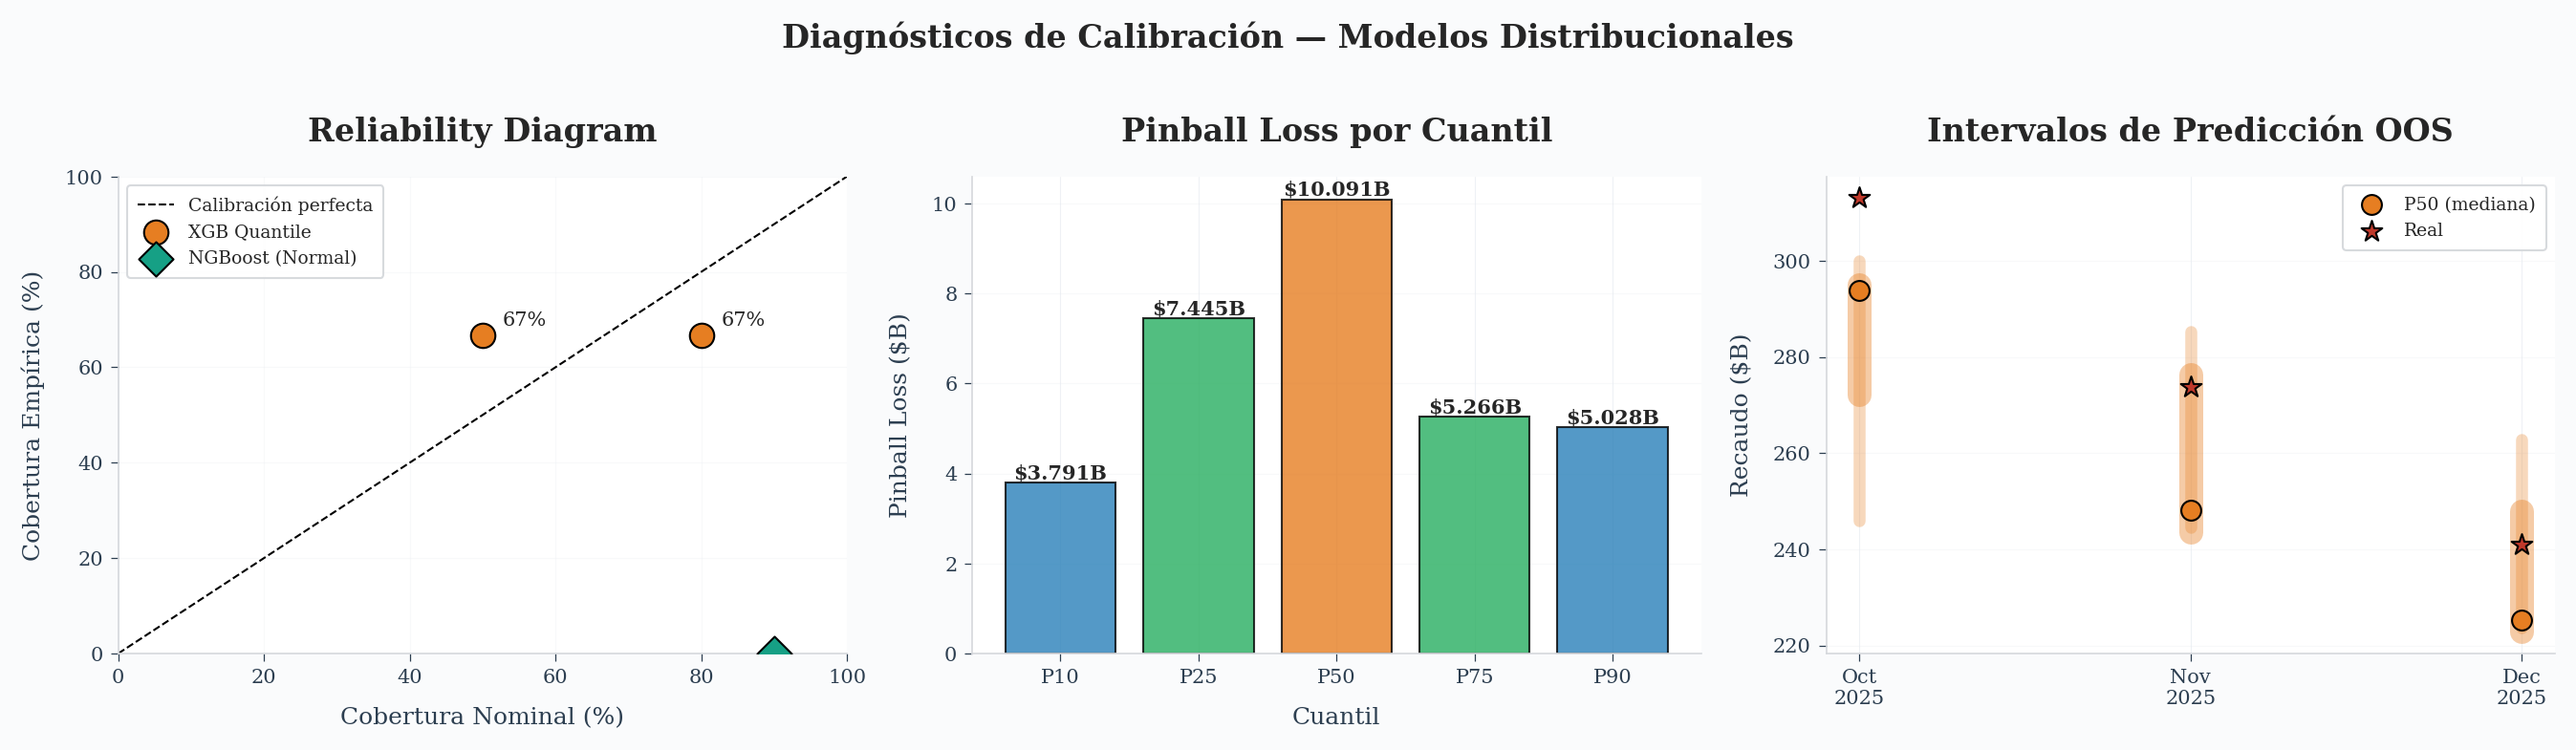

  ✅ Figura guardada: 11_distributional_calibracion.png


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE V — Calibración Probabilística y Diagnósticos
# ══════════════════════════════════════════════════════════════

# ── Reliability Diagram (Quantile Regression) ──
# Evaluar cobertura empírica para distintos niveles nominales
nominal_levels = []
empirical_coverages = []
interval_widths = []

# Pares simétricos de cuantiles: (P10,P90)=80%, (P25,P75)=50%
quantile_pairs = [(0.10, 0.90, 0.80), (0.25, 0.75, 0.50)]

for q_lo, q_hi, nominal in quantile_pairs:
    covered = np.mean(
        (y_test_raw.values >= quantile_preds_raw[q_lo]) &
        (y_test_raw.values <= quantile_preds_raw[q_hi])
    )
    width = np.mean(quantile_preds_raw[q_hi] - quantile_preds_raw[q_lo])
    nominal_levels.append(nominal * 100)
    empirical_coverages.append(covered * 100)
    interval_widths.append(width)

# ── Análisis de asimetría de los intervalos ──
# ¿La distribución del recaudo es simétrica?
asimetrias = []
for i, fecha in enumerate(X_test.index):
    p50 = quantile_preds_raw[0.50][i]
    p10 = quantile_preds_raw[0.10][i]
    p90 = quantile_preds_raw[0.90][i]
    # Ratio de asimetría: >1 = cola derecha más larga
    upper_arm = p90 - p50
    lower_arm = p50 - p10
    if lower_arm > 0:
        asimetrias.append(upper_arm / lower_arm)
    else:
        asimetrias.append(1.0)

print(f"{'═'*70}")
print(f"DIAGNÓSTICOS DE CALIBRACIÓN — Regresión Cuantílica")
print(f"{'═'*70}")
print(f"\n  Reliability (Cobertura empírica vs nominal):")
for nom, emp, w in zip(nominal_levels, empirical_coverages, interval_widths):
    status = "✅" if abs(emp - nom) <= 20 else "⚠️"
    print(f"    {status} IC {nom:.0f}%: Cobertura = {emp:.0f}% | Ancho = ${w/1e9:.1f}B")

print(f"\n  Pinball Loss por cuantil:")
total_pinball = 0
for q in QUANTILES:
    pb = pinball_scores[q]
    total_pinball += pb
    print(f"    {QUANTILE_LABELS[q]}: {pb/1e9:.3f}B")
print(f"    Total: {total_pinball/1e9:.3f}B")

print(f"\n  Asimetría de intervalos (ratio cola derecha / cola izquierda):")
for i, fecha in enumerate(X_test.index):
    print(f"    {fecha.strftime('%b %Y')}: {asimetrias[i]:.2f} {'(simétrico)' if 0.8 <= asimetrias[i] <= 1.2 else '(asimétrico)'}")

# ══════════════════════════════════════════════════════════════
# VISUALIZACIÓN 2: Diagnósticos de calibración
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Reliability Diagram
ax1 = axes[0]
ax1.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Calibración perfecta')
ax1.scatter(nominal_levels, empirical_coverages, s=150, c=C_QUINARY,
            edgecolors='black', zorder=5, label='XGB Quantile')
if NGBOOST_AVAILABLE:
    # NGBoost: IC 90%
    ax1.scatter([90], [cov90_ngb], s=150, c=C_SEPTENARY, marker='D',
                edgecolors='black', zorder=5, label=f'NGBoost ({best_ngb_dist})')
for nom, emp in zip(nominal_levels, empirical_coverages):
    ax1.annotate(f'{emp:.0f}%', (nom, emp), textcoords="offset points",
                 xytext=(10, 5), fontsize=10)
ax1.set_xlabel('Cobertura Nominal (%)', **FONT_AXIS)
ax1.set_ylabel('Cobertura Empírica (%)', **FONT_AXIS)
ax1.set_title('Reliability Diagram', **FONT_TITLE)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.legend(prop={'size': 9})
ax1.grid(True, alpha=0.3)

# Panel 2: Pinball Loss por cuantil
ax2 = axes[1]
pb_values = [pinball_scores[q] / 1e9 for q in QUANTILES]
colors = [C_TERTIARY, C_QUATERNARY, C_QUINARY, C_QUATERNARY, C_TERTIARY]
bars = ax2.bar([QUANTILE_LABELS[q] for q in QUANTILES], pb_values, color=colors,
               edgecolor='black', alpha=0.8)
for bar, val in zip(bars, pb_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'${val:.3f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xlabel('Cuantil', **FONT_AXIS)
ax2.set_ylabel('Pinball Loss ($B)', **FONT_AXIS)
ax2.set_title('Pinball Loss por Cuantil', **FONT_TITLE)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Intervalos de predicción mes a mes
ax3 = axes[2]
meses = [f.strftime('%b\n%Y') for f in X_test.index]
x_pos = np.arange(len(meses))
width_bar = 0.35

# Barras de intervalo P10–P90
for i in range(len(meses)):
    ax3.plot([x_pos[i], x_pos[i]],
             [quantile_preds_raw[0.10][i]/1e9, quantile_preds_raw[0.90][i]/1e9],
             color=C_QUINARY, linewidth=6, alpha=0.3, solid_capstyle='round')
    ax3.plot([x_pos[i], x_pos[i]],
             [quantile_preds_raw[0.25][i]/1e9, quantile_preds_raw[0.75][i]/1e9],
             color=C_QUINARY, linewidth=12, alpha=0.4, solid_capstyle='round')

ax3.scatter(x_pos, [quantile_preds_raw[0.50][i]/1e9 for i in range(len(meses))],
            s=100, c=C_QUINARY, edgecolors='black', zorder=5, label='P50 (mediana)')
ax3.scatter(x_pos, y_test_raw.values/1e9, s=120, c=C_SECONDARY,
            marker='*', edgecolors='black', zorder=6, label='Real')

ax3.set_xticks(x_pos)
ax3.set_xticklabels(meses)
ax3.set_ylabel('Recaudo ($B)', **FONT_AXIS)
ax3.set_title('Intervalos de Predicción OOS', **FONT_TITLE)
ax3.legend(prop={'size': 9})
ax3.grid(True, alpha=0.3, axis='y')

fig.suptitle('Diagnósticos de Calibración — Modelos Distribucionales',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '11_distributional_calibracion.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✅ Figura guardada: 11_distributional_calibracion.png")

## Fase VI — Pronóstico de Producción 2026 con Intervalos de Predicción

Generamos el pronóstico para los 12 meses de 2026 usando el modelo de
regresión cuantílica, proporcionando **intervalos de predicción completos**
(P10, P25, P50, P75, P90) para cada mes.

Esto permite a la ADRES planificar con tres escenarios:
- **Conservador (P10):** Mínimo creíble — base para reservas de contingencia
- **Central (P50):** Mediana — mejor estimación para presupuesto operativo
- **Optimista (P90):** Máximo razonable — techo para proyectos de inversión

In [6]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Pronóstico de Producción 2026 con Intervalos
# ══════════════════════════════════════════════════════════════

# ── Reentrenar con TODOS los datos disponibles (51 meses) ──
X_full = df_clean[FEATURES]
y_full = df_clean['y']

# Reentrenar modelos cuantílicos con datos completos
quantile_models_full = {}
for q in QUANTILES:
    params = BASE_PARAMS.copy()
    params['objective'] = 'reg:quantileerror'
    params['quantile_alpha'] = q
    model_q = xgb.XGBRegressor(**params)
    model_q.fit(X_full, y_full, verbose=False)
    quantile_models_full[q] = model_q

# Reentrenar NGBoost si disponible
if NGBOOST_AVAILABLE:
    ngb_full = NGBRegressor(
        Dist=Normal if best_ngb_dist == 'Normal' else LogNormal,
        Score=CRPScore,
        Base=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3, min_samples_split=5),
        n_estimators=300,
        learning_rate=0.05,
        natural_gradient=True,
        verbose=False,
        random_state=42
    )
    ngb_full.fit(X_full.values, y_full.values)

# ── Construir features para 2026 (rolling forecast) ──
df_2026 = df_clean.copy()
fechas_2026 = pd.date_range('2026-01-01', periods=HORIZONTE_PRONOSTICO, freq='MS')
forecast_rows = []

# Macro data 2026
macro_2026 = MACRO_DATA[2026]

for i, fecha in enumerate(fechas_2026):
    row = {}
    # Calendario
    row['Mes'] = fecha.month
    row['Trimestre'] = fecha.quarter
    row['Anio'] = fecha.year
    row['Es_Pico_Fiscal'] = int(fecha.month in MESES_PICO)
    row['Es_Festividad'] = int(fecha.month in MESES_FESTIVIDAD)
    row['Semestre'] = 1 if fecha.month <= 6 else 2

    # Tendencia (continuación)
    row['Trend'] = len(df_2026) + i
    row['Trend_sq'] = row['Trend'] ** 2

    # Lags (desde la serie extendida incluyendo pronósticos previos)
    all_y = list(df_2026['y'].values) + [r.get('y_pred_log', 0) for r in forecast_rows]
    for lag in [1, 2, 3, 12]:
        idx = len(all_y) - lag
        row[f'Lag_{lag}'] = all_y[idx] if idx >= 0 else np.nan

    # Medias móviles
    for window, name in [(3, 'MA_3'), (6, 'MA_6'), (12, 'MA_12')]:
        vals = all_y[-window:]
        row[name] = np.mean(vals) if len(vals) == window else np.nan

    # Momentum
    row['Diff_1'] = all_y[-1] - all_y[-2] if len(all_y) >= 2 else 0
    row['Diff_12'] = all_y[-1] - all_y[-13] if len(all_y) >= 13 else 0

    # Macro
    row['IPC'] = macro_2026['IPC']
    row['Salario_Minimo'] = macro_2026['Salario_Minimo']
    row['UPC'] = macro_2026['UPC']
    row['Consumo_Hogares'] = macro_2026['Consumo_Hogares']
    # SMLV_COP y IPC_Idx: escalar desde el último valor conocido
    last_smlv = df_2026['SMLV_COP'].iloc[-1] if 'SMLV_COP' in df_2026.columns else 1750905
    last_ipc_idx = df_2026['IPC_Idx'].iloc[-1] if 'IPC_Idx' in df_2026.columns else 136.68
    row['SMLV_COP'] = last_smlv * (1 + macro_2026['Salario_Minimo'] / 100)
    row['IPC_Idx'] = last_ipc_idx * (1 + macro_2026['IPC'] / 100 / 12)

    # Cíclicas
    row['Mes_sin'] = np.sin(2 * np.pi * row['Mes'] / 12)
    row['Mes_cos'] = np.cos(2 * np.pi * row['Mes'] / 12)

    # Predecir cuantiles
    X_row = pd.DataFrame([row])[FEATURES]
    preds = {}
    for q in QUANTILES:
        preds[q] = quantile_models_full[q].predict(X_row)[0]

    # Usar P50 como predicción central para lags futuros
    row['y_pred_log'] = preds[0.50]
    row['y_pred_raw'] = np.expm1(preds[0.50])
    for q in QUANTILES:
        row[f'pred_{QUANTILE_LABELS[q]}_raw'] = np.expm1(preds[q])

    # NGBoost
    if NGBOOST_AVAILABLE:
        ngb_dist_2026 = ngb_full.pred_dist(X_row.values)
        row['ngb_mu'] = np.expm1(ngb_dist_2026.loc[0])
        row['ngb_lower_90'] = np.expm1(ngb_dist_2026.dist.ppf(0.05)[0])
        row['ngb_upper_90'] = np.expm1(ngb_dist_2026.dist.ppf(0.95)[0])

    row['Fecha'] = fecha
    forecast_rows.append(row)

# ── Consolidar pronóstico ──
df_forecast = pd.DataFrame(forecast_rows)
df_forecast.set_index('Fecha', inplace=True)

# ── Tabla de resultados ──
print(f"\n{'═'*90}")
print(f"PRONÓSTICO DISTRIBUCIONAL 2026 — Rentas Cedidas (12 meses)")
print(f"{'═'*90}")
print(f"{'Mes':<10} {'P10':>12} {'P25':>12} {'P50':>12} {'P75':>12} {'P90':>12}")
print(f"{'─'*70}")
total = {q: 0 for q in QUANTILES}
for _, row in df_forecast.iterrows():
    mes = row.name.strftime('%b %Y') if hasattr(row.name, 'strftime') else str(row.name)
    vals = []
    for q in QUANTILES:
        v = row[f'pred_{QUANTILE_LABELS[q]}_raw']
        total[q] += v
        vals.append(f"${v/1e9:>9.1f}B")
    print(f"  {mes:<8} {vals[0]} {vals[1]} {vals[2]} {vals[3]} {vals[4]}")

print(f"{'─'*70}")
vals_total = [f"${total[q]/1e9:>9.1f}B" for q in QUANTILES]
print(f"  {'TOTAL':<8} {vals_total[0]} {vals_total[1]} {vals_total[2]} {vals_total[3]} {vals_total[4]}")
print(f"{'═'*90}")

rango = total[0.90] - total[0.10]
print(f"\n  Rango anual P10–P90: ${rango/1e12:.2f} billones")
print(f"  Amplitud relativa:   {rango/total[0.50]*100:.1f}% de la mediana")


══════════════════════════════════════════════════════════════════════════════════════════
PRONÓSTICO DISTRIBUCIONAL 2026 — Rentas Cedidas (12 meses)
══════════════════════════════════════════════════════════════════════════════════════════
Mes                 P10          P25          P50          P75          P90
──────────────────────────────────────────────────────────────────────
  Jan 2026 $    232.4B $    285.6B $    308.3B $    334.9B $    346.6B
  Feb 2026 $    227.1B $    275.9B $    298.2B $    293.2B $    291.2B
  Mar 2026 $    232.4B $    285.7B $    274.1B $    274.4B $    275.0B
  Apr 2026 $    203.0B $    200.2B $    197.3B $    220.0B $    256.9B
  May 2026 $    194.0B $    196.5B $    197.7B $    211.1B $    254.6B
  Jun 2026 $    225.1B $    245.9B $    224.5B $    238.2B $    267.0B
  Jul 2026 $    233.5B $    286.4B $    313.2B $    299.3B $    336.6B
  Aug 2026 $    226.8B $    264.9B $    281.3B $    287.4B $    284.3B
  Sep 2026 $    236.3B $    262.0B $    281

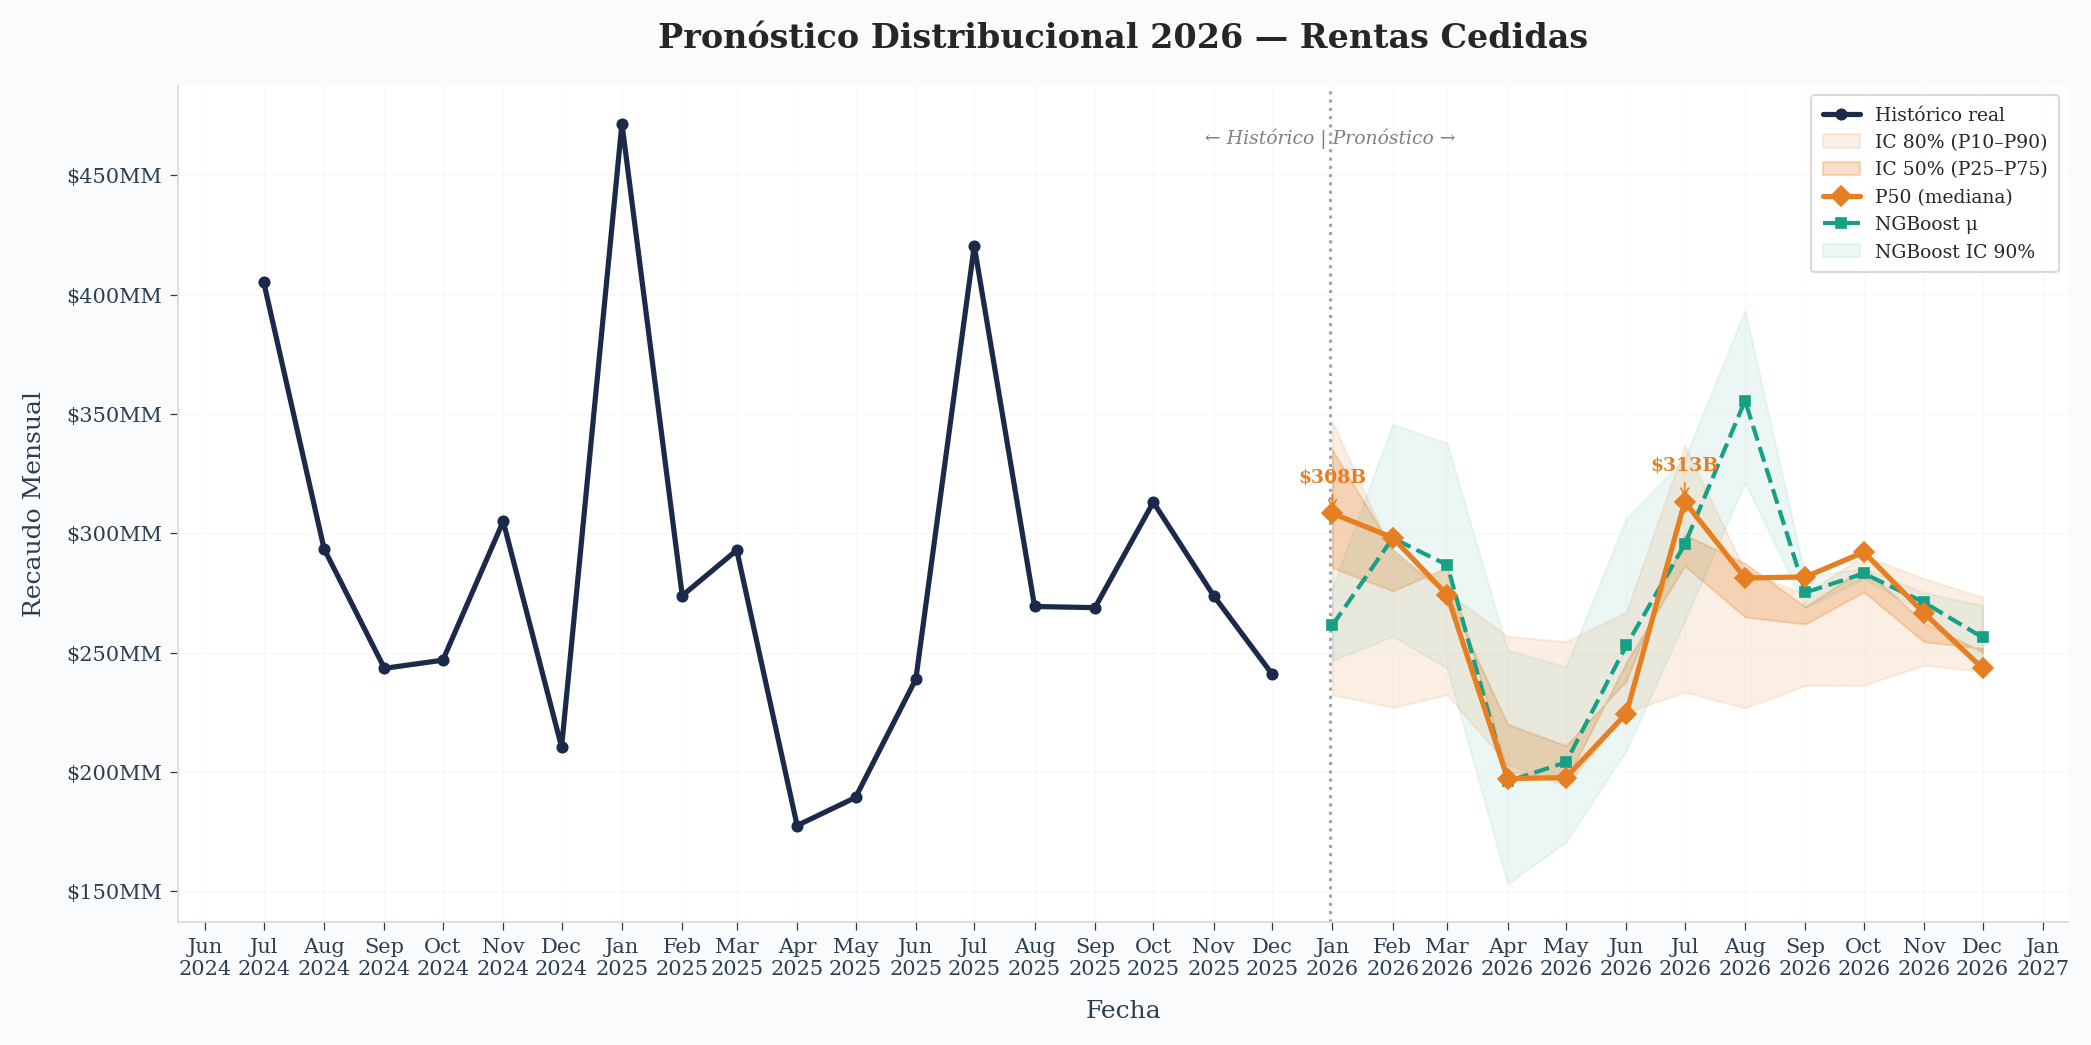

  ✅ Figura guardada: 11_distributional_forecast_2026.png


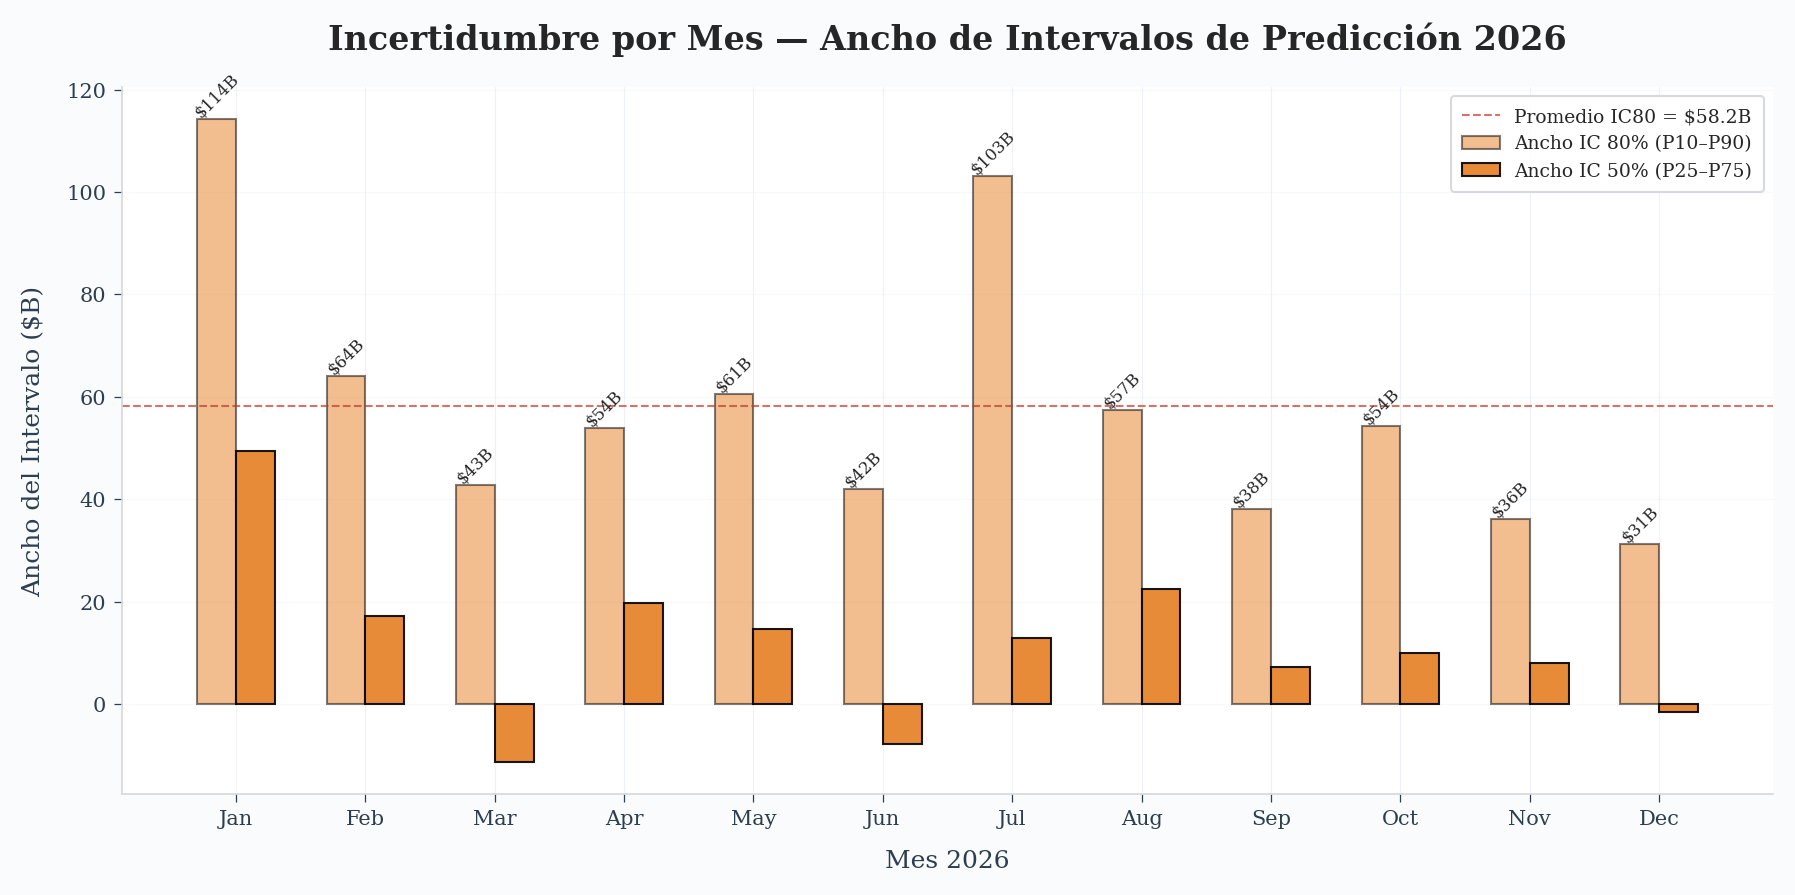

  ✅ Figura guardada: 11_distributional_uncertainty_width.png


In [7]:
# ══════════════════════════════════════════════════════════════
# VISUALIZACIÓN 3: Fan Chart — Pronóstico 2026 Distribucional
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=FIGSIZE_FULL)

# Serie histórica (últimos 18 meses)
hist_start = pd.Timestamp('2024-07-01')
serie_hist = serie.loc[hist_start:]
ax.plot(serie_hist.index, serie_hist.values, color=C_PRIMARY, linewidth=2.5,
        marker='o', markersize=5, label='Histórico real', zorder=5)

# Fan chart 2026
fechas_f = df_forecast.index
p10 = df_forecast['pred_P10_raw'].values
p25 = df_forecast['pred_P25_raw'].values
p50 = df_forecast['pred_P50_raw'].values
p75 = df_forecast['pred_P75_raw'].values
p90 = df_forecast['pred_P90_raw'].values

ax.fill_between(fechas_f, p10, p90, alpha=0.12, color=C_QUINARY, label='IC 80% (P10–P90)')
ax.fill_between(fechas_f, p25, p75, alpha=0.25, color=C_QUINARY, label='IC 50% (P25–P75)')
ax.plot(fechas_f, p50, color=C_QUINARY, linewidth=2.5, marker='D',
        markersize=7, label='P50 (mediana)', zorder=4)

# NGBoost overlay si disponible
if NGBOOST_AVAILABLE and 'ngb_mu' in df_forecast.columns:
    ax.plot(fechas_f, df_forecast['ngb_mu'].values, color=C_SEPTENARY,
            linewidth=2, linestyle='--', marker='s', markersize=5,
            label='NGBoost μ', zorder=3)
    ax.fill_between(fechas_f, df_forecast['ngb_lower_90'].values,
                    df_forecast['ngb_upper_90'].values,
                    alpha=0.08, color=C_SEPTENARY, label='NGBoost IC 90%')

# Línea de separación histórico/pronóstico
ax.axvline(x=pd.Timestamp('2025-12-31'), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.annotate('← Histórico | Pronóstico →', xy=(pd.Timestamp('2025-12-31'), ax.get_ylim()[1]*0.95),
            fontsize=9, ha='center', color='gray', style='italic')

# Anotaciones de meses pico
for i, fecha in enumerate(fechas_f):
    if fecha.month in MESES_PICO:
        ax.annotate(f'${p50[i]/1e9:.0f}B',
                    xy=(fecha, p50[i]),
                    textcoords="offset points", xytext=(0, 15),
                    fontsize=9, fontweight='bold', color=C_QUINARY,
                    ha='center',
                    arrowprops=dict(arrowstyle='->', color=C_QUINARY, lw=0.8))

ax.set_title('Pronóstico Distribucional 2026 — Rentas Cedidas', **FONT_TITLE)
ax.set_xlabel('Fecha', **FONT_AXIS)
ax.set_ylabel('Recaudo Mensual', **FONT_AXIS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(loc='upper right', prop={'size': 9}, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '11_distributional_forecast_2026.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✅ Figura guardada: 11_distributional_forecast_2026.png")

# ══════════════════════════════════════════════════════════════
# VISUALIZACIÓN 4: Comparación de Anchura de IC por mes
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)

meses_labels = [f.strftime('%b') for f in fechas_f]
x_pos = np.arange(len(meses_labels))

ic_80 = (p90 - p10) / 1e9
ic_50 = (p75 - p25) / 1e9

ax.bar(x_pos - 0.15, ic_80, width=0.3, color=C_QUINARY, alpha=0.5,
       edgecolor='black', label='Ancho IC 80% (P10–P90)')
ax.bar(x_pos + 0.15, ic_50, width=0.3, color=C_QUINARY, alpha=0.9,
       edgecolor='black', label='Ancho IC 50% (P25–P75)')

# Línea promedio
ax.axhline(y=np.mean(ic_80), color=C_SECONDARY, linestyle='--', linewidth=1, alpha=0.7,
           label=f'Promedio IC80 = ${np.mean(ic_80):.1f}B')

for i, v in enumerate(ic_80):
    ax.text(x_pos[i] - 0.15, v + 0.5, f'${v:.0f}B', ha='center', fontsize=8, rotation=45)

ax.set_xticks(x_pos)
ax.set_xticklabels(meses_labels)
ax.set_xlabel('Mes 2026', **FONT_AXIS)
ax.set_ylabel('Ancho del Intervalo ($B)', **FONT_AXIS)
ax.set_title('Incertidumbre por Mes — Ancho de Intervalos de Predicción 2026', **FONT_TITLE)
ax.legend(prop={'size': 9})
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '11_distributional_uncertainty_width.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✅ Figura guardada: 11_distributional_uncertainty_width.png")

In [8]:
# ══════════════════════════════════════════════════════════════
# EXPORTACIÓN DE RESULTADOS
# ══════════════════════════════════════════════════════════════

# ── 1. Pronóstico 2026 con cuantiles ──
export_cols = ['pred_P10_raw', 'pred_P25_raw', 'pred_P50_raw', 'pred_P75_raw', 'pred_P90_raw']
df_export = df_forecast[export_cols].copy()
df_export.columns = ['P10', 'P25', 'P50_Mediana', 'P75', 'P90']
df_export.index.name = 'Fecha'
df_export.to_csv(OUTPUTS_FORECASTS / 'distributional_forecast_2026.csv')
print(f"  ✅ outputs/forecasts/distributional_forecast_2026.csv")

# ── 2. Métricas OOS ──
metrics_data = {
    'Modelo': ['XGBoost Quantile (P50)'],
    'MAPE_%': [mape_qr],
    'RMSE_B': [rmse_qr / 1e9],
    'MAE_B': [mae_qr / 1e9],
    'Cobertura_IC80_%': [cov_80_qr],
    'Cobertura_IC50_%': [cov_50_qr],
}
if NGBOOST_AVAILABLE:
    metrics_data['Modelo'].append(f'NGBoost ({best_ngb_dist})')
    metrics_data['MAPE_%'].append(mape_ngb)
    metrics_data['RMSE_B'].append(rmse_ngb / 1e9)
    metrics_data['MAE_B'].append(mae_ngb if mae_ngb else 0)
    metrics_data['Cobertura_IC80_%'].append(0)  # NGBoost usa IC90
    metrics_data['Cobertura_IC50_%'].append(0)

df_metrics = pd.DataFrame(metrics_data)
df_metrics.to_csv(OUTPUTS_REPORTS / 'distributional_metricas.csv', index=False)
print(f"  ✅ outputs/reports/distributional_metricas.csv")

# ── 3. Pinball Loss detallado ──
df_pinball = pd.DataFrame({
    'Cuantil': [QUANTILE_LABELS[q] for q in QUANTILES],
    'Tau': QUANTILES,
    'Pinball_Loss_B': [pinball_scores[q] / 1e9 for q in QUANTILES],
})
df_pinball.to_csv(OUTPUTS_REPORTS / 'distributional_pinball_loss.csv', index=False)
print(f"  ✅ outputs/reports/distributional_pinball_loss.csv")

# ══════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO
# ══════════════════════════════════════════════════════════════
sep = '=' * 70
print(f"\n{sep}")
print("RESUMEN EJECUTIVO — Regresion Distribucional")
print(sep)

_w = f"${interval_width/1e9:.1f}B"
_t10 = f"${total[0.10]/1e12:.2f}"
_t50 = f"${total[0.50]/1e12:.2f}"
_t90 = f"${total[0.90]/1e12:.2f}"
_rng = f"${rango/1e12:.2f}"
_pct = f"{rango/total[0.50]*100:.1f}%"

print(f"  1. PREDICCION PUNTUAL (P50):")
print(f"     XGBoost Quantile P50: MAPE = {mape_qr:.2f}%")
if NGBOOST_AVAILABLE:
    print(f"     NGBoost ({best_ngb_dist}): MAPE = {mape_ngb:.2f}%")
print(f"     XGBoost Puntual (ref): MAPE = {mape_xgb_ref:.2f}%")
print(f"  2. INTERVALOS DE PREDICCION (OOS):")
print(f"     Cobertura IC 80% (P10-P90): {cov_80_qr:.0f}%")
print(f"     Cobertura IC 50% (P25-P75): {cov_50_qr:.0f}%")
print(f"     Ancho promedio IC 80%: {_w}")
print(f"  3. PRONOSTICO ANUAL 2026:")
print(f"     P10 (conservador):  {_t10} billones")
print(f"     P50 (central):      {_t50} billones")
print(f"     P90 (optimista):    {_t90} billones")
print(f"     Rango P10-P90:      {_rng} billones ({_pct} de la mediana)")
print(f"  4. VALOR PARA LA GESTION PRESUPUESTAL:")
print(f"     El escenario P10 define el piso para reservas de contingencia")
print(f"     El P50 (mediana) es mas robusto que la media ante outliers")
print(f"     El rango P10-P90 cuantifica la incertidumbre fiscal real")
print(f"     La asimetria de los intervalos revela el perfil de riesgo mes a mes")
print(sep)
print(f"  Artefactos generados: 4 figuras + 3 CSVs")
print(f"  Notebook: 11_Distributional_Regression.ipynb")
print(sep)

  ✅ outputs/forecasts/distributional_forecast_2026.csv
  ✅ outputs/reports/distributional_metricas.csv
  ✅ outputs/reports/distributional_pinball_loss.csv

RESUMEN EJECUTIVO — Regresion Distribucional
  1. PREDICCION PUNTUAL (P50):
     XGBoost Quantile P50: MAPE = 7.34%
     NGBoost (Normal): MAPE = 4.14%
     XGBoost Puntual (ref): MAPE = 3.36%
  2. INTERVALOS DE PREDICCION (OOS):
     Cobertura IC 80% (P10-P90): 67%
     Cobertura IC 50% (P25-P75): 67%
     Ancho promedio IC 80%: $44.6B
  3. PRONOSTICO ANUAL 2026:
     P10 (conservador):  $2.73 billones
     P50 (central):      $3.18 billones
     P90 (optimista):    $3.43 billones
     Rango P10-P90:      $0.70 billones (22.0% de la mediana)
  4. VALOR PARA LA GESTION PRESUPUESTAL:
     El escenario P10 define el piso para reservas de contingencia
     El P50 (mediana) es mas robusto que la media ante outliers
     El rango P10-P90 cuantifica la incertidumbre fiscal real
     La asimetria de los intervalos revela el perfil de riesg